# Improting libraires and dataset

In [2]:
# Importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style ="whitegrid")

# importing dataset

ttc_data = pd.read_csv("Titanic-Dataset.csv")

print("The first 5 rows of the dataset")
print(ttc_df.head())
ttc_data

The first 5 rows of the dataset
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [3]:
print("The summary of the data")
print(ttc_data.info())

The summary of the data
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


Age has 714 non-null rows that indicates that 177 values are missing.
Embarked has 889 non-null rows that shows that 2 values are missing.
Cabin has maximum missing data that contains only 204 non-null rows, it is neccessary to abandon all completely to retain the data clean.

# Finding and handling the missing values

In [7]:
ttc_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
AgeGroup       0
dtype: int64

In [8]:
Data Cleaning Validation
Verification Status: All columns have successfully been processed and contain zero missing values.

Data Integrity: The inclusion of the new FamilySize and AgeGroup features shows that all transformations were applied correctly without introducing any null entries. The dataset is now fully prepared for exploratory data analysis and visualization.

The missing value after cleaning
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
FamilySize     0
AgeGroup       0
dtype: int64


Verification Status: All columns have effectively been analyzed and consist zero missing values.

Data Integrity: The integration of the new FamilySize and AgeGroup features displays that each and every shifts were utilized accurately without presenting any void entries. The dataset is now completely organized for exploratory data analysis and visualization.

# Feature Engineering

In [12]:
# build FamilySize 

ttc_data["FamilySize"] = ttc_data["SibSp"] + ttc_data["Parch"]

# Create age group

ttc_data["AgeGroup"] = pd.cut(
    ttc_data["Age"], 
    bins=[0, 12, 18, 30, 50, 80], 
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)

# Preview the new columns to ensure they were created correctly
print(ttc_data[["Name", "Age", "AgeGroup", "SibSp", "Parch", "FamilySize"]].head())

                                                Name   Age    AgeGroup  SibSp  \
0                            Braund, Mr. Owen Harris  22.0  YoungAdult      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  38.0       Adult      1   
2                             Heikkinen, Miss. Laina  26.0  YoungAdult      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  35.0       Adult      1   
4                           Allen, Mr. William Henry  35.0       Adult      0   

   Parch  FamilySize  
0      0           1  
1      0           1  
2      0           0  
3      0           1  
4      0           0  


FamilySize: It successfully collects SibSp & Parch like Passenger 0 had 1 sibling/spouse and 0 parents/children, suitably following in a family size of 1.

Age Categorization: Continuous ages have been successfully outlined into systematic demographic groups. Specifically, ages 22 and 26 are precisely structured as YoungAdult, while ages 35 and 38 are suitably discarded as Adult. This allows to concerntrate seperated survival guide with specific life steps rather than strewed individual ages.

# Visualizations & Dashboard

/Users/prithvisadanand/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


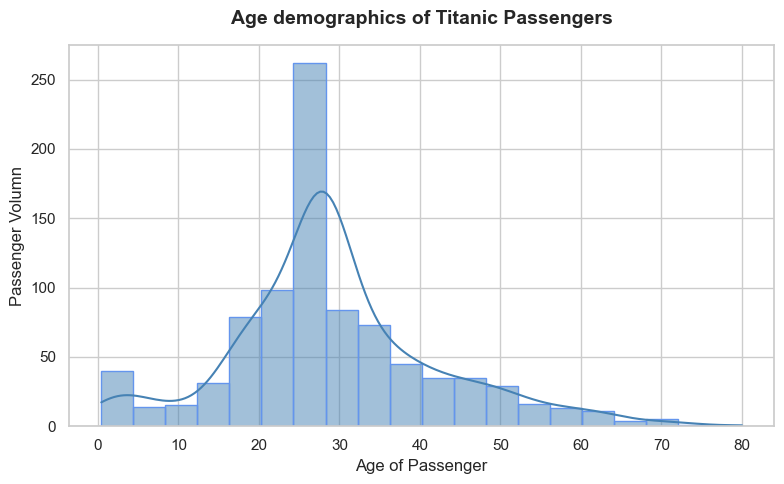

In [14]:
# Create a single plot figure
plt.figure(figsize=(8, 5))

# Plot the histogram with a Kernel Density Estimate (KDE) line
sns.histplot(ttc_data["Age"], bins=20, kde=True, color="steelblue", edgecolor="cornflowerblue")

# Add precise chart decorations for a professional finish
plt.title("Age demographics of Titanic Passengers", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Age of Passenger", fontsize=12)
plt.ylabel("Passenger Volumn", fontsize=12)

# Display the plot cleanly
plt.tight_layout()
plt.show()

### Age Distribution Analysis

* **Observation:** The histogram exposes that the generality of passengers on the Titanic were focused in the 20 to 35 age range, which aligns to the "YoungAdult" and "Adult" sections.
* **Takeaway:** This signifies that the ship's demographic was mainly structured of young to middle-aged adults, probably displaying the working-age population traveling for migration or business.

# Bar Chart - Survival Rate by Sex

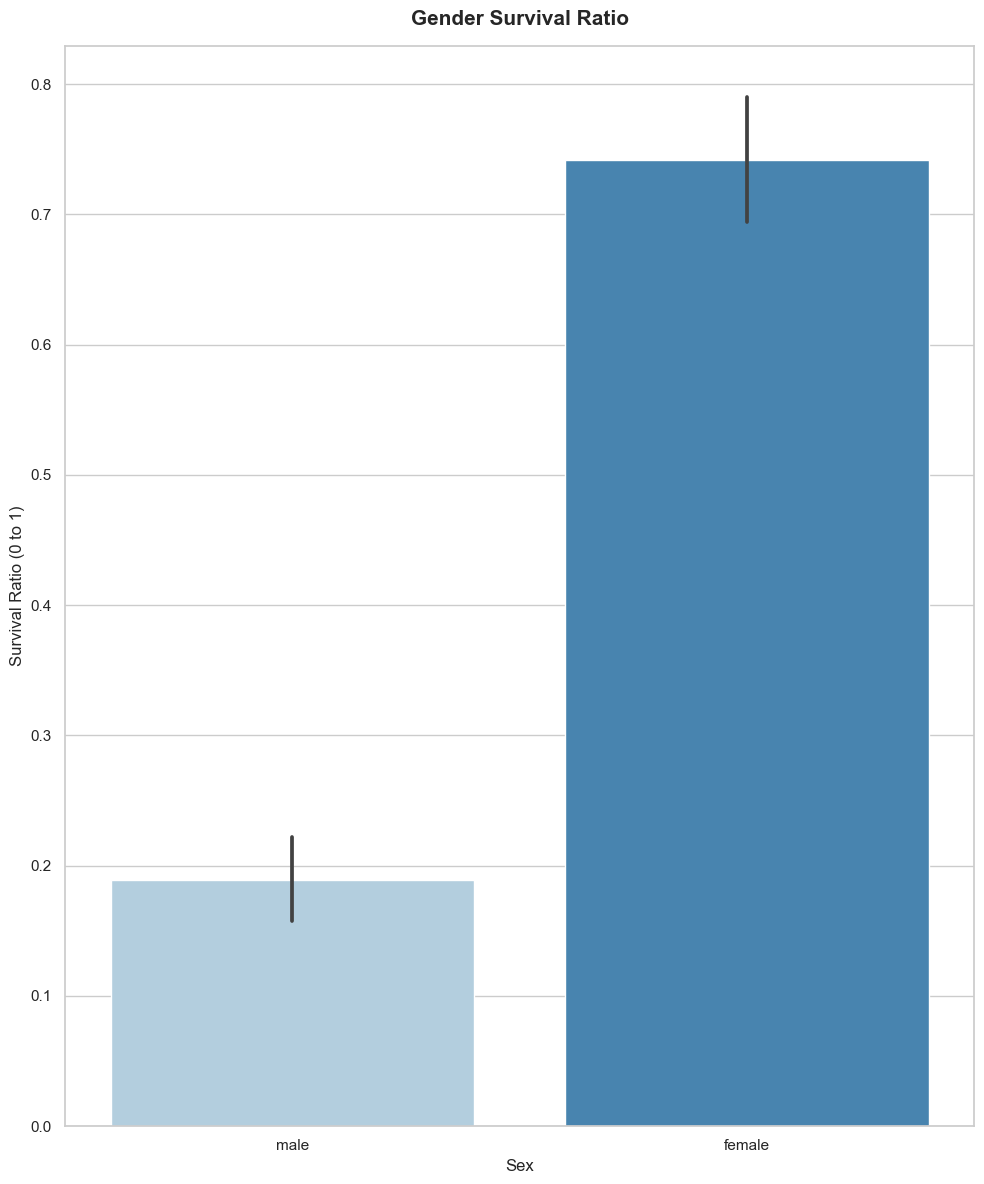

In [15]:
# Create the bar plot
plt.figure(figsize=(10, 12))
sns.barplot(x="Sex", y="Survived", data=ttc_data, palette="Blues")

# Add chart decorations
plt.title("Gender Survival Ratio", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Sex", fontsize=12)
plt.ylabel("Survival Ratio (0 to 1)", fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

### 4.2 Survival Rate by Gender
* **Observation:** The plot shows a substantially maximum survival rate for female passengers weighed to male passengers.
* **Takeaway:** This robustly reccoment that gender was a key feature in survival priority during the disaster, likely following the "women and children first" protocol during the evacuation of the ship.

# Boxplot - Fare by Passenger Class

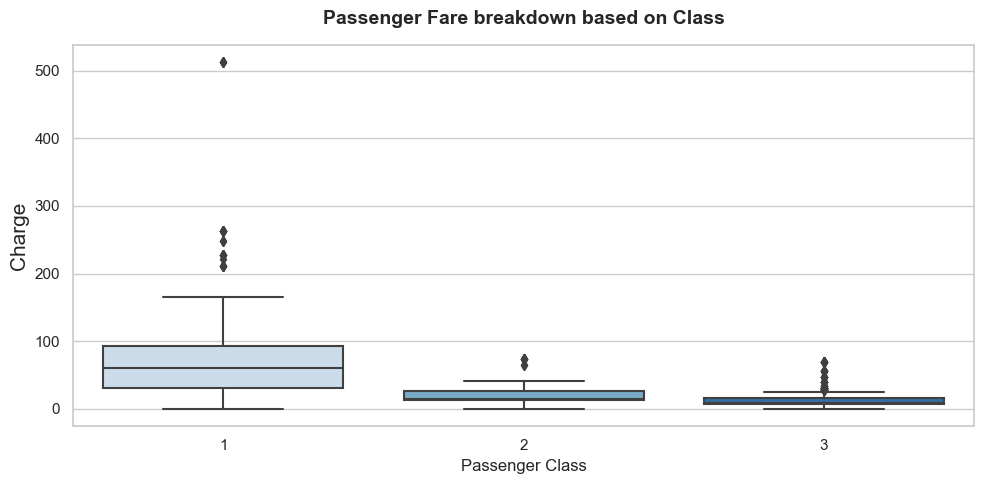

In [17]:
# Create the boxplot
plt.figure(figsize=(10, 5))
sns.boxplot(x="Pclass", y="Fare", data=ttc_data, palette="Blues")

# Add chart decorations
plt.title("Passenger Fare breakdown based on Class", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Passenger Class", fontsize=12)
plt.ylabel("Charge", fontsize=15)

# Display the plot
plt.tight_layout()
plt.show()

# 4.3 Fare Distribution by Passenger Class
* **Observation:** The boxplot clear vision of First Class (Class 1) passengers paid significantly higher fares on average and exhibit more extreme outliers compared to Second and Third Class passengers. 
* **Takeaway:** This demonstrates a high correlation between passenger class and financial status, with First Class tickets having a much wider and more expensive distribution, while Third Class fares are tightly clustered at the lower end.

# Scatterplot - Age vs. Fare

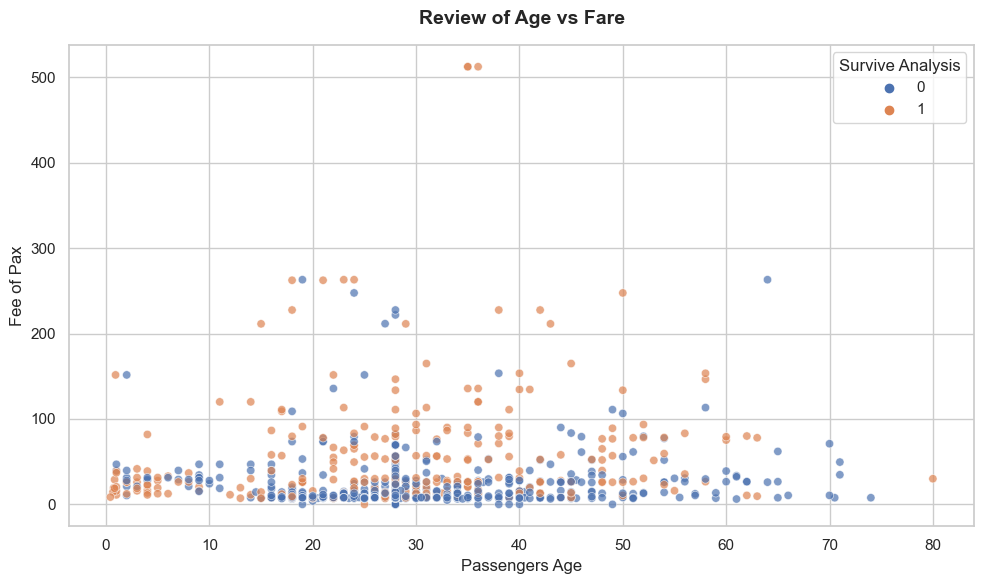

In [18]:
# Create the scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(x="Age", y="Fare", hue="Survived", data=ttc_data, alpha=0.7, palette="deep")

# Add chart decorations
plt.title("Review of Age vs Fare", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Passengers Age", fontsize=12)
plt.ylabel("Fee of Pax", fontsize=12)
plt.legend(title="Survive Analysis")

# Display the plot
plt.tight_layout()
plt.show()

### 4.4 Age vs. Fare (Survival Analysis)
* **Observation:** The plot displays that passengers who funded higher fares has a greeater chance to survive, and these survivors are expanded over different age sector. Remarkably, the high-fare passengers are grouped in the middle age ranges.
* **Takeaway:** This strengthens the concept that Class-based status (signified by the cost) performed a role in survival, likely resulting from cabin location and proximity to lifeboats on the ship.

# Heatmap - Correlations

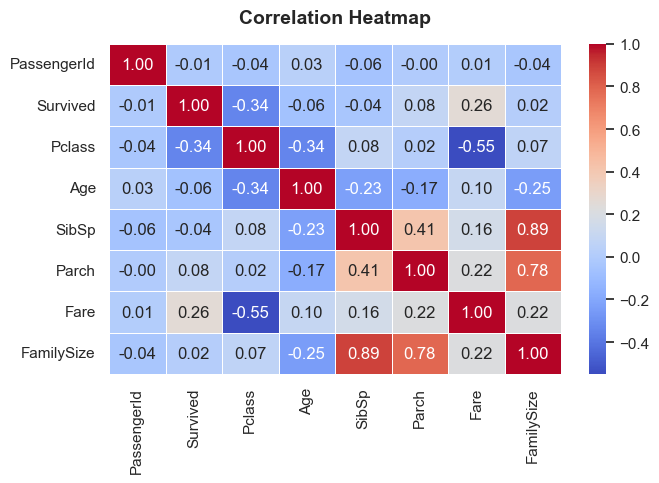

In [20]:
# Create the correlation matrix
corr_matrix = ttc_data.select_dtypes(include=[np.number]).corr()

# Create the heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)

# Add chart decoration
plt.title("Correlation Heatmap", fontsize=14, fontweight='bold', pad=15)

# Display the plot
plt.tight_layout()
plt.show()

### 4.5 Correlation Heatmap Analysis
* **Observation:** The heatmap showcases a overwhelmingly contrary correlation between `Pclass` and `Fare`, which is anticipated as lower class numbers (1st class) coincide to higher fares. There is also a striking negative correlation between `Pclass` and `Survived`, recommending that passengers in higher classes had a higher probability of survival.
* **Takeaway:** This matrix confirms the interdependencies we observed in earlier plots, mathematically proving that socioeconomic factors (class and fare) were highly influential variables in determining passenger survival.

## 5. Conclusion
This analysis of the Titanic dataset has given a chance to get a clear evidence of how demographic and socioeconomic factors impacted survival. Major takeaways consists:
* **Demographics:** The passenger list was governed by young and middle-aged adults.
* **Survival Disparities:** Gender and social class were the most substantial predictors of survival, consistent with historical accounts of the disaster.
* **Data Utility:** By cleaning the dataset and engineering new features like `FamilySize` and `AgeGroup`, we were able to transform raw data into a compelling visual narrative.